# Value Function Iteration: On-grid & Off-grid

First, consider a general dynamic programming problem. In this case we typically want to solve an optimization problem over time. For example:

$$
V(k) = \max_{a \in \mathcal{A}(k)} \left\{ u(k, a) + \beta V(f(k, a)) \right\}
$$

* $V(k)$: value function at state $k$
* $u(k, a)$: current utility given action $a$
* $f(k, a)$: state transition
* $\beta \in (0, 1)$: discount factor

This is the **Bellman equation**. Solving it gives us the optimal value function $V^*$. Which usually looks something like:

<img src="Figures/true_V.png" width="60%">

A common way to solve this is by **value function iteration**, which repeatedly applies the **Bellman operator**:

$$
T(V)(k) = \max_{a \in \mathcal{A}(k)} \left\{ u(k, a) + \beta V(f(k, a)) \right\}
$$

This allows us to obtain $V^*$, thanks to the **Contraction Mapping Theorem**. This theorem states:

Let $T$ be a **contraction mapping** on a **complete metric space** $(K, d)$, i.e., there exists $0 < \beta < 1$ such that for all $k_a, k_b \in K$,

$$
d(T(k_a), T(k_b)) \leq \beta d(k_a, k_b)
$$

Then:
* $T$ has a **unique fixed point** $k^* \in K$ such that $T(k^*) = k^*$
* Starting from any $k_0 \in K$, the sequence $k_{n+1} = T(k_n)$ converges to $k^*$

To apply this to dynamic programming:

* We define a space of value functions $V: \mathcal{K} \to \mathbb{R}$, often with the **sup norm** $\|V - W\| = \sup_{k} |V(k) - W(k)|$
* The Bellman operator $T$ maps one value function to another
* If the **discount factor** $\beta < 1$ and **utilities are bounded**, then the Bellman operator $T$ is a **contraction**:

  $$
  \|T(V) - T(W)\| \leq \beta \|V - W\|
  $$

Thus, by the **Contraction Mapping Theorem**:

* $T$ has a **unique fixed point** $V^*$, which is the **solution to the Bellman equation**
* Repeatedly applying $T$ (i.e., **value function iteration**) starting from any $V_0$ will converge to $V^*$


✅ In words: Based on your guess for $V(k)$, the contraction mapping theorem gives you a better (in the sense of closer to the true value) answer of what $V(k)$ is. If you repeat this several times eventually you reach the true answer (i.e. the fixed point). This holds regardless of your initial guess (i.e. where you start) as long as $\beta < 1$.


In this tutorial we are going to take a look at two ways to apply VFI.

1. VFI On-grid
    * You force all next-period states to be exact points on the grid (Either by restricting your actions or rounding the result)
    * Pros: Simple to implement and fast and easy to store values (i.e. just look them up from the grid)
    * Cons: Inaccurate if the real next state often falls between grid points


<img src="Figures/on-grid.png" width="60%">


2. VFI Off grid (with interpolation)
    * You allow next-period states to be anywhere, even between grid points (interpolating between points)
    * Pros: More accurate and allows more flexible choices
    * Cons: Requires interpolation (linear, splines, etc.), which makes it slower.


<img src="Figures/off-grid.png" width="60%">


---

## 1. Setup

In this Tutorial we are going to apply VFI to an infinite horizon version of the two-period model we solved in Tutorial 2. Additionally, we are going to consider that income follows an AR(1) as in Tutorial 4.

In [17]:
using Parameters, Setfield, Plots, CubicSplines, Optim

### 1.1 Numerical Parameters

In [18]:
@with_kw struct NumericalParameters
    nk   = 100       # Number of asset grid points
    nz   = 2         # Number of income states
    crit = 1.0e-5    # Convergence tolerance
    maxk = 10.0      # Maximum assets
    mink = -9/4      # Minimum assets (borrowing limit)
end
n_par = NumericalParameters()
println(n_par)

NumericalParameters
  nk: Int64 100
  nz: Int64 2
  crit: Float64 1.0e-5
  maxk: Float64 10.0
  mink: Float64 -2.25



### 1.2 Economic Parameters

In [19]:
@with_kw struct ModelParameters
    r  = 4/90        # Interest rate
    ξ  = 1.0         # CRRA coefficient
    β  = 0.95        # Discount factor
    b  = n_par.mink  # Borrowing limit
    ρ  = 0.98        # AR(1) persistence
end
m_par = ModelParameters()
println(m_par)

ModelParameters
  r: Float64 0.044444444444444446
  ξ: Float64 1.0
  β: Float64 0.95
  b: Float64 -2.25
  ρ: Float64 0.98



### 1.3 Discretize Income (Tauchen)

In [20]:
include("Tauchen.jl")
grid_z, Π, bounds = Tauchen(m_par.ρ, n_par.nz)
grid_z = exp.(grid_z)  # transform to levels

2-element Vector{Float64}:
 0.45028049832185046
 2.2208379082081016

### 1.4 Grids and Utility

#### Asset & Income Grids

In [21]:
gri = (
    k = exp.(range(log(1), log(n_par.maxk - n_par.mink + 1); length = n_par.nk)) .- 1 .+ n_par.mink,
    z = grid_z
)

(k = [-2.25, -2.223555400864301, -2.1964114849051537, -2.168549758969494, -2.1399512408602366, -2.1105964464037053, -2.08046537617506, -2.049537501872689, -2.017791752332272, -1.9852064991709968  …  7.226018410369241, 7.5030525177696585, 7.787412681087201, 8.079292634933832, 8.37889123715569, 8.686412604314915, 9.002066250754334, 9.326067231339557, 9.658636287975938, 10.0], z = [0.45028049832185046, 2.2208379082081016])

#### Utility Functions

In [22]:
if m_par.ξ == 1.0
    util(c)      = log.(c)
    mutil(c)     = 1.0 ./ c
    invmutil(mu) = 1.0 ./ mu
else
    util(c)      = 1.0/(1.0 - m_par.ξ) .* c.^(1 - m_par.ξ)
    mutil(c)     = 1.0 ./ (c .^ m_par.ξ)
    invmutil(mu) = (1.0 ./ mu).^(1.0 / m_par.ξ)
end

invmutil (generic function with 1 method)

---

## 2. Implementation: VFI On-grid 

Classic brute-force method that evaluates and stores the value function only at the grid points.

**Approach:** Maximize over all pairs `(k, k')` restricted to the discrete grid.

In [23]:
# Precompute meshes for fast vectorized VFI
meshes = (
    kprime = [kp for kp in gri.k, k in gri.k, z in gri.z],
    k      = [k  for kp in gri.k, k in gri.k, z in gri.z],
    z      = [z  for kp in gri.k, k in gri.k, z in gri.z]
)

# Cash and consumption arrays
y  = meshes.z .+ meshes.k .* (1 + m_par.r)
c  = y .- meshes.kprime

# Utility matrix with -Inf for infeasible
U = fill(-1e10, size(c))
U[c .> 0] = util(c[c .> 0])

# Initialize V and policy
V       = zeros(n_par.nk, n_par.nz)
kprime_on = zeros(n_par.nk, n_par.nz)
dist_on = [Inf]
iter = 1

V_hist_on = [copy(V)]  # store each iterate (Not needed but I do it to show convergence)
t = time()
while dist_on[end] > n_par.crit
    EV     = m_par.β .* (V * Π')             # expected continuation value
    TV     = U .+ repeat(reshape(EV, n_par.nk, 1, n_par.nz), outer=(1, n_par.nk, 1))

    Vnew, arg = dropdims(maximum(TV, dims=1), dims=1), dropdims(argmax(TV, dims=1), dims=1)
    # arg gives (1, nk, nz) cartesian index → pick second = k' index
    kprime_on .= [gri.k[i[2]] for i in arg]

    dist = maximum(abs.(Vnew - V))
    push!(dist_on, dist)
    V = Vnew
    push!(V_hist_on, copy(V))  # record (again only for convergence animation)
    iter += 1
end
time_on = time() - t
V_on     = V

100×2 Matrix{Float64}:
 -6.59862   5.2716
 -6.52272   5.29435
 -6.44881   5.31755
 -6.37499   5.3414
 -6.3012    5.3656
 -6.22732   5.39057
 -6.15332   5.41643
 -6.07876   5.44254
 -6.00312   5.46952
 -5.92716   5.49678
  ⋮        
  5.29113  11.6093
  5.51227  11.7516
  5.73546  11.8951
  5.96116  12.0412
  6.18887  12.1873
  6.41909  12.3331
  6.65122  12.4785
  6.88566  12.6231
  7.12188  12.7667

**Key step:** We build a 3D array `TV[k', k, z]`, maximize over the **first** dimension, and recover the optimal `k'` from `argmax` indices.

┌ Info: Saved animation to /Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 5/vfi_on_convergence.gif
└ @ Plots /Users/albert/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 5/vfi_on_convergence.gif")
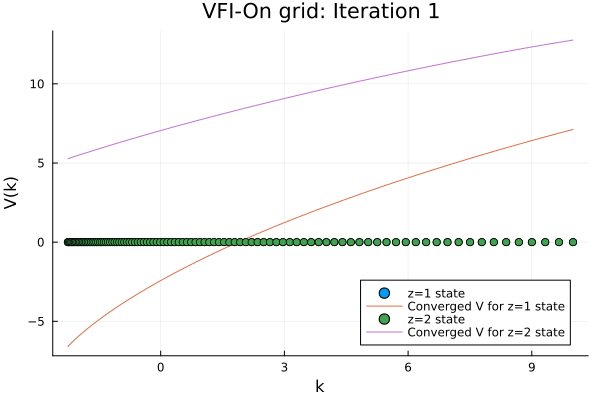

In [24]:
true_V = V_hist_on[end]

anim = @animate for (n, Vn) in enumerate(V_hist_on)
    scatter(gri.k, Vn[:,1], label="z=1 state", legend=:bottomright)
    plot!(gri.k, true_V[:,1], label="Converged V for z=1 state")
    scatter!(gri.k, Vn[:,2], label="z=2 state")
    plot!(gri.k, true_V[:,2], label="Converged V for z=2 state")
    title!("VFI-On grid: Iteration $n")
    xlabel!("k")
    ylabel!("V(k)")
end

gif(anim, "vfi_on_convergence.gif", fps=8)

---

## 3. Implementation: VFI Off-grid

Accuracy-oriented variant that allows evaluation between grid points via interpolation (or other basis functions).

**Approach:** For each `(k, z)`, solve a continuous maximization using **cubic spline** interpolation of `V` and `Optim.optimize`.

In [25]:
# Cash-at-hand for off-grid (no mesh for k')
meshes2 = (
    k = [k for k in gri.k, z in gri.z],
    z = [z for k in gri.k, z in gri.z]
)
y2 = meshes2.z .+ meshes2.k .* (1 + m_par.r)

# Initialize
V       = zeros(n_par.nk, n_par.nz)
kprime_off = zeros(n_par.nk, n_par.nz)
dist_off = [Inf]
iter = 1

V_hist_off = [copy(V)] # store each iterate (Not needed but I do it to show convergence)
t = time()
while dist_off[end] > n_par.crit
    EV = m_par.β .* (V * Π')  # expected value
    Vnew = similar(V)

    for z_i in 1:n_par.nz
        spline_EV = CubicSpline(gri.k, EV[:, z_i])
        for k_i in 1:n_par.nk
            f_obj(kp) = -(util(y2[k_i, z_i] - kp) + spline_EV(kp))
            res = optimize(f_obj, m_par.b, min(y2[k_i, z_i], n_par.maxk))
            Vnew[k_i, z_i]     = -Optim.minimum(res)
            kprime_off[k_i, z_i] = Optim.minimizer(res)
        end
    end

    dist = maximum(abs.(Vnew - V))
    push!(dist_off, dist)
    V = Vnew
    push!(V_hist_off, copy(V))  # record (again only for convergence animation)
    iter += 1
end
time_off = time() - t
V_off     = V

100×2 Matrix{Float64}:
 -6.5931    5.28167
 -6.51719   5.30442
 -6.44289   5.32771
 -6.36904   5.35156
 -6.29532   5.37598
 -6.22132   5.40099
 -6.14704   5.42659
 -6.07224   5.45279
 -5.99686   5.47962
 -5.92087   5.50708
  ⋮        
  5.30641  11.6221
  5.52696  11.7639
  5.74983  11.907
  5.97502  12.0513
  6.20249  12.1965
  6.43221  12.3422
  6.66415  12.4878
  6.89825  12.6323
  7.13443  12.7736

**Key step:** We interpolate `EV(k')` to allow a continuous optimizer over `kp ∈ [b, min(cash, maxk)]`.

┌ Info: Saved animation to /Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 5/vfi_off_convergence.gif
└ @ Plots /Users/albert/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/Users/albert/Dropbox/0_Teaching/Tuebingen/SoSe 2025/Adv. Macro II/Tutorials/Tutorial 5/vfi_off_convergence.gif")
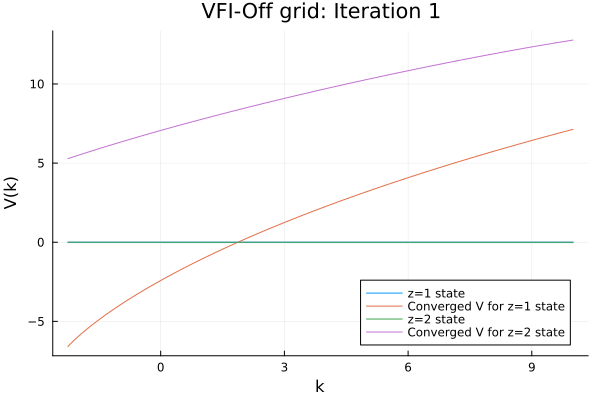

In [26]:
true_V = V_hist_off[end]

anim = @animate for (n, Vn) in enumerate(V_hist_off)
    plot(gri.k, Vn[:,1], label="z=1 state", legend=:bottomright)
    plot!(gri.k, true_V[:,1], label="Converged V for z=1 state")
    plot!(gri.k, Vn[:,2], label="z=2 state")
    plot!(gri.k, true_V[:,2], label="Converged V for z=2 state")
    title!("VFI-Off grid: Iteration $n")
    xlabel!("k")
    ylabel!("V(k)")
end

gif(anim, "vfi_off_convergence.gif", fps=8)

---

## 5. Visual Comparison between two types of VFI

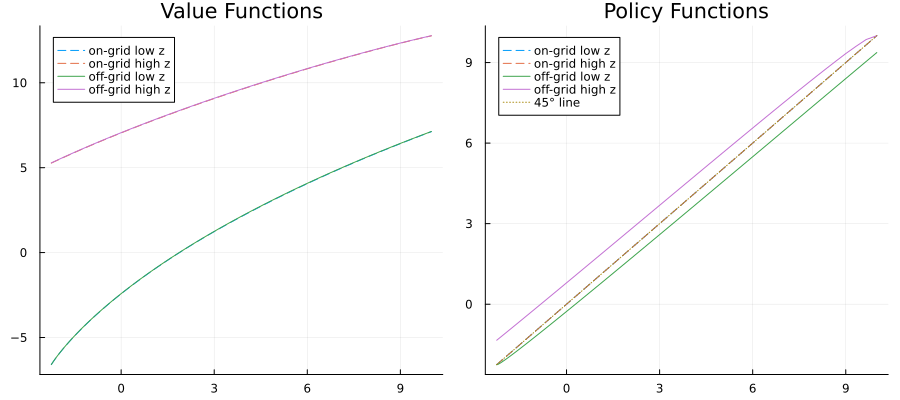

In [27]:
# Value functions
p1 = plot(gri.k, V_on[:,1], linestyle=:dash, label="on-grid low z")
plot!(gri.k, V_on[:,2], linestyle=:dash, label="on-grid high z")
plot!(gri.k, V_off[:,1], label="off-grid low z")
plot!(gri.k, V_off[:,2], label="off-grid high z")
title!("Value Functions")

# Policy functions
p2 = plot(gri.k, kprime_on[:,1], linestyle=:dash, label="on-grid low z")
plot!(gri.k, kprime_on[:,2], linestyle=:dash, label="on-grid high z")
plot!(gri.k, kprime_off[:,1], label="off-grid low z")
plot!(gri.k, kprime_off[:,2], label="off-grid high z")
plot!(gri.k, gri.k, linestyle=:dot, label="45° line")
title!("Policy Functions")

plot(p1, p2, layout=(1,2), size=(900,400))

## 6. Performance & Convergence

In [28]:
time_on, time_off, last(dist_on), last(dist_off)

(0.05863809585571289, 1.1424200534820557, 9.902144984863526e-6, 9.946885569434016e-6)

You’ll typically see:

* `time_off ≫ time_on` (slower per iteration)
* `last(dist_off) < last(dist_on)` (tighter convergence for off-grid)